# NB03: Explaining PA14 Inhibition — Single Organisms

**Project**: CF Protective Microbiome Formulation Design  
**Goal**: Test H1 — does metabolic overlap with PA14 predict % inhibition? Decompose the variance: metabolic overlap, growth kinetics, taxonomy, and residual (direct antagonism).

This is the core analysis that determines whether the "eat their lunch" design principle is supported by experimental data.

**Input**: `data/isolate_master.tsv` (NB01), `data/kinetic_advantage.tsv` (NB02)  
**Output**: `data/single_isolate_scores.tsv`, model diagnostics

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

DATA = Path('..') / 'data'
FIGS = Path('..') / 'figures'
GOLD = Path.home() / 'protect' / 'gold'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

master = pd.read_csv(DATA / 'isolate_master.tsv', sep='\t')
print(f'Master table: {len(master)} isolates')
print(f'With inhibition: {master.has_inhibition.sum()}')

Master table: 429 isolates
With inhibition: 142


## 1. EDA: Inhibition Data for the Analysis Cohort

Focus on the 142 isolates with BOTH inhibition scores and carbon utilization data.

In [2]:
# Analysis cohort: isolates with inhibition + carbon utilization
cohort = master[master.has_inhibition].copy()
print(f'Analysis cohort: {len(cohort)} isolates')
print(f'Species represented: {cohort.species.nunique()}')
print(f'Genera represented: {cohort.genus.nunique()}')
print(f'\nInhibition distribution:')
print(cohort.best_pct_inhibition.describe().round(1).to_string())
print(f'\nMetabolic overlap distribution:')
print(cohort.metabolic_overlap_pa14.describe().round(3).to_string())

Analysis cohort: 142 isolates
Species represented: 62
Genera represented: 33

Inhibition distribution:
count    142.0
mean      25.4
std       27.9
min      -38.7
25%        7.6
50%       14.7
75%       38.3
max      101.6

Metabolic overlap distribution:
count    142.000
mean       0.268
std        0.117
min        0.175
25%        0.200
50%        0.218
75%        0.274
max        0.711


In [3]:
# Metabolic features: compute additional scores
carbon_sources = ['glucose', 'lactate', 'serine', 'threonine', 'alanine',
                  'glycine', 'proline', 'isoleucine', 'leucine', 'valine', 'aspartate',
                  'glutamate', 'phenylalanine', 'tryptophan', 'lysine', 'histidine',
                  'arginine', 'ornithine', 'cystein', 'methionine']

# PA14-preferred substrates (OD > 0.2 from NB01)
pa14_preferred = ['proline', 'histidine', 'ornithine', 'glutamate', 'aspartate',
                  'isoleucine', 'arginine', 'lactate', 'leucine', 'alanine', 'glucose']

# Sum of growth on PA14-preferred substrates
cohort['growth_on_pa_preferred'] = cohort[pa14_preferred].sum(axis=1)

# Number of PA14-preferred substrates the commensal can use (OD > 0.1)
cohort['n_pa_substrates_used'] = (cohort[pa14_preferred] > 0.1).sum(axis=1)

# Total metabolic breadth (any substrate OD > 0.1)
cohort['metabolic_breadth'] = (cohort[carbon_sources] > 0.1).sum(axis=1)

# Max growth on any single substrate
cohort['max_growth'] = cohort[carbon_sources].max(axis=1)

print('Feature summary:')
for feat in ['metabolic_overlap_pa14', 'growth_on_pa_preferred', 'n_pa_substrates_used', 
             'metabolic_breadth', 'max_growth']:
    print(f'  {feat}: mean={cohort[feat].mean():.3f}, std={cohort[feat].std():.3f}')

Feature summary:
  metabolic_overlap_pa14: mean=0.268, std=0.117
  growth_on_pa_preferred: mean=0.835, std=0.546
  n_pa_substrates_used: mean=1.725, std=2.975
  metabolic_breadth: mean=2.345, std=4.122
  max_growth: mean=0.136, std=0.101


## 2. Univariate Analysis: Metabolic Overlap vs Inhibition

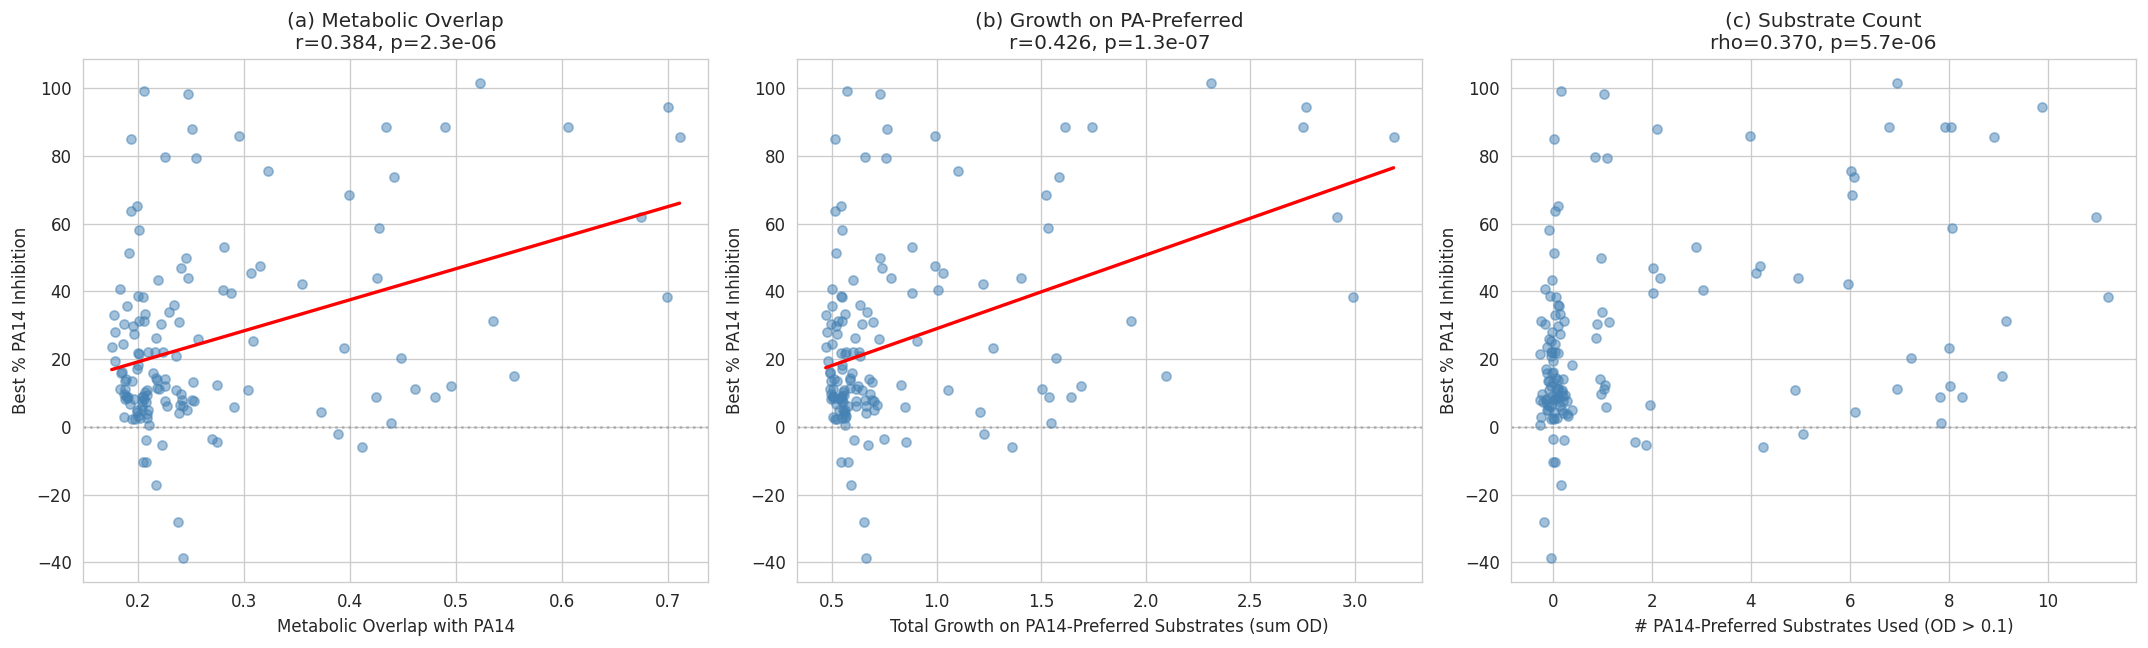

In [4]:
# Scatter with regression line and genus coloring
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) Metabolic overlap
ax = axes[0]
ax.scatter(cohort.metabolic_overlap_pa14, cohort.best_pct_inhibition, alpha=0.5, s=30, c='steelblue')
# Regression line
slope, intercept, r, p, se = stats.linregress(cohort.metabolic_overlap_pa14, cohort.best_pct_inhibition)
x_line = np.linspace(cohort.metabolic_overlap_pa14.min(), cohort.metabolic_overlap_pa14.max(), 100)
ax.plot(x_line, intercept + slope * x_line, 'r-', linewidth=2)
ax.set_xlabel('Metabolic Overlap with PA14')
ax.set_ylabel('Best % PA14 Inhibition')
ax.set_title(f'(a) Metabolic Overlap\nr={r:.3f}, p={p:.1e}')
ax.axhline(0, color='grey', ls=':', alpha=0.5)

# (b) Growth on PA-preferred substrates
ax = axes[1]
ax.scatter(cohort.growth_on_pa_preferred, cohort.best_pct_inhibition, alpha=0.5, s=30, c='steelblue')
slope2, intercept2, r2, p2, _ = stats.linregress(cohort.growth_on_pa_preferred, cohort.best_pct_inhibition)
x_line2 = np.linspace(cohort.growth_on_pa_preferred.min(), cohort.growth_on_pa_preferred.max(), 100)
ax.plot(x_line2, intercept2 + slope2 * x_line2, 'r-', linewidth=2)
ax.set_xlabel('Total Growth on PA14-Preferred Substrates (sum OD)')
ax.set_ylabel('Best % PA14 Inhibition')
ax.set_title(f'(b) Growth on PA-Preferred\nr={r2:.3f}, p={p2:.1e}')
ax.axhline(0, color='grey', ls=':', alpha=0.5)

# (c) Number of PA substrates used
ax = axes[2]
ax.scatter(cohort.n_pa_substrates_used + np.random.normal(0, 0.15, len(cohort)), 
           cohort.best_pct_inhibition, alpha=0.5, s=30, c='steelblue')
r3, p3 = stats.spearmanr(cohort.n_pa_substrates_used, cohort.best_pct_inhibition)
ax.set_xlabel('# PA14-Preferred Substrates Used (OD > 0.1)')
ax.set_ylabel('Best % PA14 Inhibition')
ax.set_title(f'(c) Substrate Count\nrho={r3:.3f}, p={p3:.1e}')
ax.axhline(0, color='grey', ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig(FIGS / '03_metabolic_features_vs_inhibition.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Taxonomic Effects

Some genera may be intrinsically better inhibitors regardless of metabolic overlap (e.g., bacteriocin producers).

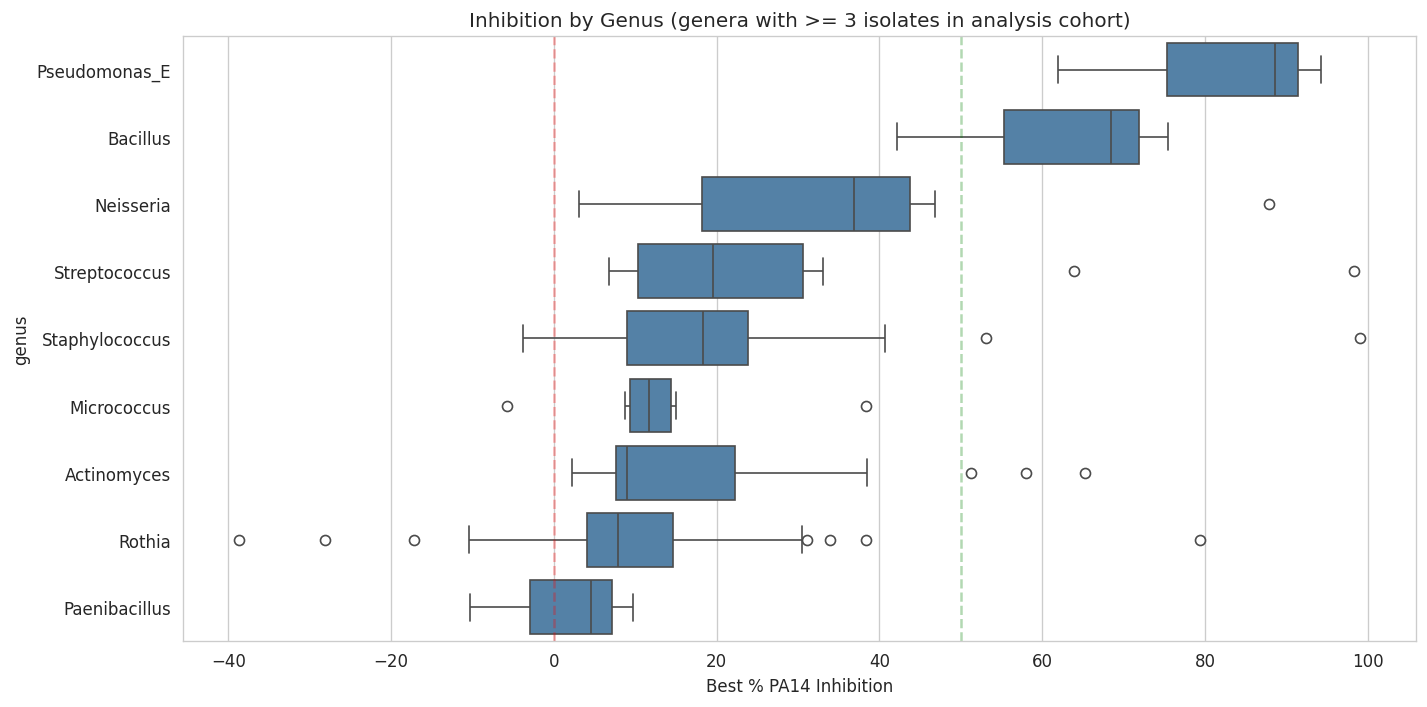

Kruskal-Wallis (genus effect): H=30.1, p=2.01e-04


In [5]:
# Inhibition by genus (genera with >= 3 isolates)
genus_counts = cohort.genus.value_counts()
multi_genus = genus_counts[genus_counts >= 3].index
cohort_multi = cohort[cohort.genus.isin(multi_genus)]

fig, ax = plt.subplots(figsize=(12, 6))
genus_order = cohort_multi.groupby('genus')['best_pct_inhibition'].median().sort_values(ascending=False).index
sns.boxplot(data=cohort_multi, y='genus', x='best_pct_inhibition', order=genus_order,
            color='steelblue', ax=ax)
ax.axvline(0, color='red', ls='--', alpha=0.3)
ax.axvline(50, color='green', ls='--', alpha=0.3)
ax.set_xlabel('Best % PA14 Inhibition')
ax.set_title('Inhibition by Genus (genera with >= 3 isolates in analysis cohort)')
plt.tight_layout()
plt.savefig(FIGS / '03_inhibition_by_genus_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# Kruskal-Wallis: does genus explain inhibition?
groups = [g.best_pct_inhibition.values for _, g in cohort_multi.groupby('genus')]
h_stat, kw_p = stats.kruskal(*groups)
print(f'Kruskal-Wallis (genus effect): H={h_stat:.1f}, p={kw_p:.2e}')

## 4. Multivariate Model: What Predicts Inhibition?

Regression: inhibition ~ metabolic_overlap + growth_on_pa + metabolic_breadth + genus

In [6]:
# OLS: metabolic features only
model_data = cohort[['best_pct_inhibition', 'metabolic_overlap_pa14', 'growth_on_pa_preferred',
                     'n_pa_substrates_used', 'metabolic_breadth', 'max_growth', 'genus']].dropna()

# Model 1: metabolic overlap only
m1 = smf.ols('best_pct_inhibition ~ metabolic_overlap_pa14', data=model_data).fit()
print('=== Model 1: Metabolic Overlap Only ===')
print(f'R² = {m1.rsquared:.4f}, Adj R² = {m1.rsquared_adj:.4f}')
print(f'metabolic_overlap_pa14: coef={m1.params["metabolic_overlap_pa14"]:.1f}, p={m1.pvalues["metabolic_overlap_pa14"]:.2e}')

# Model 2: all metabolic features
m2 = smf.ols('best_pct_inhibition ~ metabolic_overlap_pa14 + growth_on_pa_preferred + metabolic_breadth + max_growth', 
             data=model_data).fit()
print(f'\n=== Model 2: All Metabolic Features ===')
print(f'R² = {m2.rsquared:.4f}, Adj R² = {m2.rsquared_adj:.4f}')
print(m2.summary().tables[1])

# Model 3: metabolic + genus (top genera only for power)
top_genera = genus_counts[genus_counts >= 5].index.tolist()
model_data['genus_group'] = model_data.genus.where(model_data.genus.isin(top_genera), 'Other')
m3 = smf.ols('best_pct_inhibition ~ metabolic_overlap_pa14 + growth_on_pa_preferred + C(genus_group)', 
             data=model_data).fit()
print(f'\n=== Model 3: Metabolic + Genus ===')
print(f'R² = {m3.rsquared:.4f}, Adj R² = {m3.rsquared_adj:.4f}')
print(f'\nVariance explained:')
print(f'  Metabolic overlap alone: {m1.rsquared:.1%}')
print(f'  All metabolic features:  {m2.rsquared:.1%}')
print(f'  Metabolic + genus:       {m3.rsquared:.1%}')
print(f'  Genus adds:              {m3.rsquared - m2.rsquared:.1%}')

=== Model 1: Metabolic Overlap Only ===
R² = 0.1413, Adj R² = 0.1351
metabolic_overlap_pa14: coef=89.5, p=4.71e-06

=== Model 2: All Metabolic Features ===
R² = 0.2739, Adj R² = 0.2524
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 62.1163     20.045      3.099      0.002      22.473     101.760
metabolic_overlap_pa14  -548.2188    166.564     -3.291      0.001    -877.632    -218.806
growth_on_pa_preferred   115.0146     30.632      3.755      0.000      54.435     175.595
metabolic_breadth          1.2175      1.746      0.697      0.487      -2.235       4.670
max_growth                82.6908     49.554      1.669      0.097     -15.312     180.694

=== Model 3: Metabolic + Genus ===
R² = 0.3599, Adj R² = 0.3208

Variance explained:
  Metabolic overlap alone: 14.1%
  All metabolic features:  27.4%
  Metabolic + genus:      

In [7]:
# Residual analysis: who inhibits MORE than predicted by metabolism?
model_data['predicted'] = m2.predict(model_data)
model_data['residual'] = model_data['best_pct_inhibition'] - model_data['predicted']

# High-residual isolates: strong inhibition unexplained by metabolism = potential direct antagonists
# Attach isolate IDs and species to model data
model_data['asma_id'] = cohort.loc[model_data.index, 'asma_id'].values
model_data['species'] = cohort.loc[model_data.index, 'species'].values

print('Top 15 isolates: inhibition EXCEEDS metabolic prediction (potential direct antagonists):')
top_resid = model_data.nlargest(15, 'residual')
print(top_resid[['asma_id', 'species', 'best_pct_inhibition', 'predicted', 'residual', 
                 'metabolic_overlap_pa14']].round(1).to_string(index=False))

print(f'\nTop 10 isolates: inhibition BELOW metabolic prediction (metabolism alone not sufficient):')
bot_resid = model_data.nsmallest(10, 'residual')
print(bot_resid[['asma_id', 'species', 'best_pct_inhibition', 'predicted', 'residual',
                 'metabolic_overlap_pa14']].round(1).to_string(index=False))

Top 15 isolates: inhibition EXCEEDS metabolic prediction (potential direct antagonists):
  asma_id                    species  best_pct_inhibition  predicted  residual  metabolic_overlap_pa14
ASMA-3016 Staphylococcus epidermidis                 99.1       21.4      77.7                     0.2
 ASMA-737   Streptococcus salivarius                 98.3       24.2      74.1                     0.2
ASMA-3044          Gemella sanguinis                 85.0       22.8      62.2                     0.2
ASMA-3643           Neisseria mucosa                 87.8       30.6      57.2                     0.3
ASMA-1662          Bacillus_A cereus                 79.5       23.5      56.1                     0.2
 ASMA-687    Serratia_J liquefaciens                 86.0       31.6      54.3                     0.3
ASMA-2935        Rothia dentocariosa                 79.4       27.9      51.4                     0.3
 ASMA-683    Serratia_J liquefaciens                 88.5       40.7      47.8         

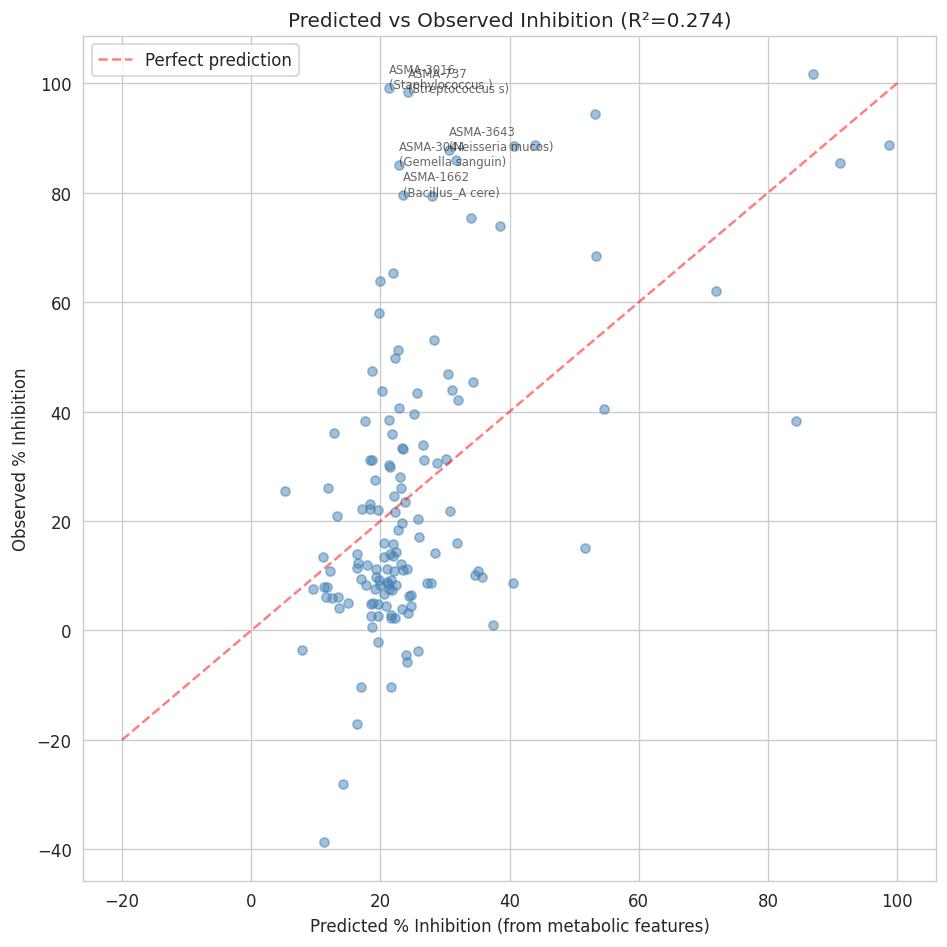

In [8]:
# Predicted vs observed scatter
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(model_data.predicted, model_data.best_pct_inhibition, alpha=0.5, s=30, c='steelblue')
ax.plot([-20, 100], [-20, 100], 'r--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Predicted % Inhibition (from metabolic features)')
ax.set_ylabel('Observed % Inhibition')
ax.set_title(f'Predicted vs Observed Inhibition (R²={m2.rsquared:.3f})')
ax.legend()

# Annotate top residual outliers
for _, row in top_resid.head(5).iterrows():
    ax.annotate(f"{row.asma_id}\n({row.species[:15]})", 
                (row.predicted, row.best_pct_inhibition),
                fontsize=7, alpha=0.7, ha='left')

plt.tight_layout()
plt.savefig(FIGS / '03_predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

### Cross-Validation

5-fold cross-validation to assess generalizability of the metabolic model.

In [9]:
# Cross-validation: 5-fold CV for the metabolic overlap model
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

X = cohort[['metabolic_overlap_pa14', 'growth_on_pa_preferred', 'metabolic_breadth', 'max_growth']].dropna()
y = cohort.loc[X.index, 'best_pct_inhibition']

lr = LinearRegression()
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')
print(f'5-fold CV R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'Fold scores: {[f"{s:.3f}" for s in cv_scores]}')
print(f'Training R² (full data): {m2.rsquared:.3f}')
print(f'CV vs training gap: {m2.rsquared - cv_scores.mean():.3f}')
if m2.rsquared - cv_scores.mean() < 0.05:
    print('Minimal overfitting — model generalizes well.')
else:
    print('Some overfitting detected — interpret R² conservatively.')


5-fold CV R²: 0.145 ± 0.142
Fold scores: ['0.118', '0.383', '-0.049', '0.192', '0.081']
Training R² (full data): 0.274
CV vs training gap: 0.129
Some overfitting detected — interpret R² conservatively.


## 5. Incorporate Growth Kinetics (for 32 isolates with curves)

Isolates with inhibition + carbon util + growth kinetics: 29


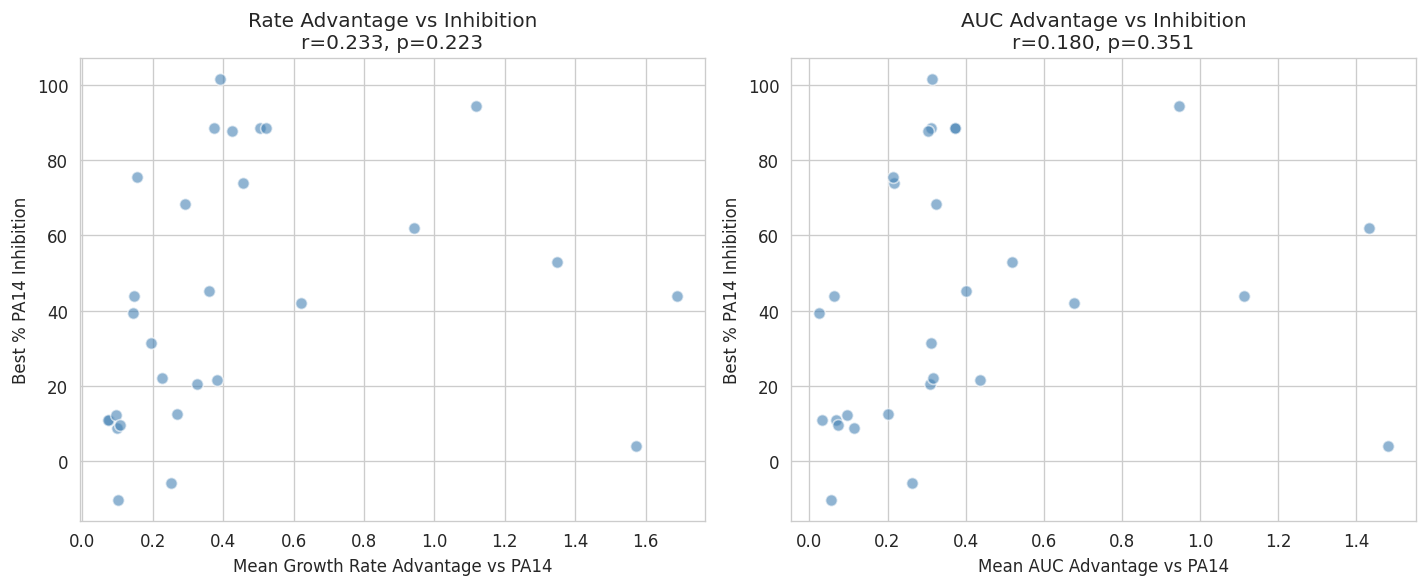


=== Model with Kinetics (n=29) ===
R² = 0.3115
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -7.9696     16.349     -0.487      0.630     -41.641      25.702
metabolic_overlap_pa14   127.2697     41.842      3.042      0.005      41.094     213.445
mean_rate_advantage       37.1487     25.798      1.440      0.162     -15.984      90.282
mean_auc_advantage       -36.5036     30.797     -1.185      0.247     -99.931      26.924


In [10]:
# Load kinetic advantage data from NB02 (if available)
kinetic_file = DATA / 'isolate_kinetic_summary.tsv'
if kinetic_file.exists():
    kinetic = pd.read_csv(kinetic_file, sep='\t')
    # Merge with cohort
    cohort_kin = cohort.merge(kinetic[['asma_id', 'mean_rate_advantage', 'mean_lag_advantage', 
                                       'mean_auc_advantage', 'n_faster']], 
                              on='asma_id', how='inner')
    print(f'Isolates with inhibition + carbon util + growth kinetics: {len(cohort_kin)}')
    
    # Does rate advantage predict inhibition beyond metabolic overlap?
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    ax = axes[0]
    ax.scatter(cohort_kin.mean_rate_advantage, cohort_kin.best_pct_inhibition, 
              alpha=0.6, s=50, c='steelblue', edgecolors='white')
    r_rate, p_rate = stats.pearsonr(cohort_kin.mean_rate_advantage, cohort_kin.best_pct_inhibition)
    ax.set_xlabel('Mean Growth Rate Advantage vs PA14')
    ax.set_ylabel('Best % PA14 Inhibition')
    ax.set_title(f'Rate Advantage vs Inhibition\nr={r_rate:.3f}, p={p_rate:.3f}')
    
    ax = axes[1]
    ax.scatter(cohort_kin.mean_auc_advantage, cohort_kin.best_pct_inhibition,
              alpha=0.6, s=50, c='steelblue', edgecolors='white')
    r_auc, p_auc = stats.pearsonr(cohort_kin.mean_auc_advantage, cohort_kin.best_pct_inhibition)
    ax.set_xlabel('Mean AUC Advantage vs PA14')
    ax.set_ylabel('Best % PA14 Inhibition')
    ax.set_title(f'AUC Advantage vs Inhibition\nr={r_auc:.3f}, p={p_auc:.3f}')
    
    plt.tight_layout()
    plt.savefig(FIGS / '03_kinetic_advantage_vs_inhibition.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Model with kinetics
    m_kin = smf.ols('best_pct_inhibition ~ metabolic_overlap_pa14 + mean_rate_advantage + mean_auc_advantage', 
                    data=cohort_kin).fit()
    print(f'\n=== Model with Kinetics (n={len(cohort_kin)}) ===')
    print(f'R² = {m_kin.rsquared:.4f}')
    print(m_kin.summary().tables[1])
else:
    print('NB02 kinetic data not yet available. Run NB02 first for kinetic analysis.')
    cohort_kin = pd.DataFrame()

## 6. Single Isolate Ranking

Rank all isolates by a composite score combining metabolic overlap, measured inhibition, and safety.

In [11]:
# Build single-isolate score for all candidates with carbon utilization data
scores = master.copy()

# Metabolic score (normalized 0-1)
scores['metabolic_score'] = scores.metabolic_overlap_pa14 / scores.metabolic_overlap_pa14.max()

# Inhibition score (normalized, 0 if no data)
scores['inhibition_score'] = scores.best_pct_inhibition.clip(lower=0).fillna(0) / 100

# Safety flag: known opportunistic pathogens
unsafe_genera = ['Pseudomonas', 'Klebsiella', 'Acinetobacter', 'Serratia', 'Serratia_J',
                 'Citrobacter', 'Citrobacter_B', 'Enterococcus', 'Enterobacter',
                 'Stenotrophomonas', 'Burkholderia', 'Ralstonia', 'Escherichia',
                 'Bacillus_A']  # B. cereus group
scores['is_safe'] = ~scores.genus.isin(unsafe_genera)

# Composite score
scores['composite_score'] = (0.4 * scores.metabolic_score + 
                             0.6 * scores.inhibition_score) * scores.is_safe.astype(int)

# Top candidates
# Exclude isolates with unknown species (APA20000/APA20015 are controls, ASMA-1309/2475/765 have genus only)
scores.loc[scores.species.isna() | (scores.species == ''), 'composite_score'] = 0
top_candidates = scores[scores.is_safe & scores.has_inhibition & scores.species.notna() & (scores.species != '')].nlargest(20, 'composite_score')
print('Top 20 Safe Single-Isolate Candidates:')
print(top_candidates[['asma_id', 'species', 'genus', 'metabolic_overlap_pa14', 
                       'best_pct_inhibition', 'composite_score', 'has_growth_curves']].round(3).to_string(index=False))

# Save
scores.to_csv(DATA / 'single_isolate_scores.tsv', sep='\t', index=False)
print(f'\nSaved scores for {len(scores)} isolates to {DATA}/single_isolate_scores.tsv')

Top 20 Safe Single-Isolate Candidates:
  asma_id                    species          genus  metabolic_overlap_pa14  best_pct_inhibition  composite_score  has_growth_curves
ASMA-2985     Pseudomonas_E juntendi  Pseudomonas_E                   0.700               94.312            0.889               True
ASMA-2777   Leclercia adecarboxylata      Leclercia                   0.522              101.604            0.851               True
ASMA-2795        Pseudomonas_E fulva  Pseudomonas_E                   0.605               88.660            0.812               True
 ASMA-737   Streptococcus salivarius  Streptococcus                   0.247               98.303            0.704              False
ASMA-3016 Staphylococcus epidermidis Staphylococcus                   0.205               99.051            0.689              False
ASMA-3404    Pseudomonas_E siliginis  Pseudomonas_E                   0.675               61.945            0.683               True
ASMA-3643           Neisseria 

In [12]:
# Summary
print('=' * 60)
print('NB03 SUMMARY')
print('=' * 60)
print(f'Analysis cohort: {len(cohort)} isolates with inhibition + carbon util')
print(f'\nH1 (metabolic competition):')
print(f'  Metabolic overlap vs inhibition: r={r:.3f}, p={p:.1e}')
print(f'  Metabolic overlap R²:            {m1.rsquared:.1%}')
print(f'  All metabolic features R²:       {m2.rsquared:.1%}')
print(f'  Metabolic + genus R²:            {m3.rsquared:.1%}')
if len(cohort_kin) > 0:
    print(f'  Metabolic + kinetics R² (n={len(cohort_kin)}): {m_kin.rsquared:.1%}')
print(f'\nSafe candidates with >50% inhibition: {len(scores[(scores.is_safe) & (scores.best_pct_inhibition > 50)])}')
print(f'Total safe candidates with inhibition data: {len(scores[scores.is_safe & scores.has_inhibition])}')

NB03 SUMMARY
Analysis cohort: 142 isolates with inhibition + carbon util

H1 (metabolic competition):
  Metabolic overlap vs inhibition: r=0.384, p=2.3e-06
  Metabolic overlap R²:            14.1%
  All metabolic features R²:       27.4%
  Metabolic + genus R²:            36.0%
  Metabolic + kinetics R² (n=29): 31.2%

Safe candidates with >50% inhibition: 17
Total safe candidates with inhibition data: 129
